# LAB-D2-04 SOLUTION: PyTorch Autograd - Break It and Fix It

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Objectives:** `OBJ-D2-01`, `OBJ-D2-02`, `OBJ-D2-05`, `OBJ-D2-07`, `OBJ-D2-08`  
**Reference environment:** local CPU; Python 3.11+; PyTorch, NumPy, matplotlib, scikit-learn; no download  
**Expected compute runtime:** complete baseline and all-card reference path under 6 minutes  
**Execution contract:** Clear outputs, restart the kernel, and run all cells from top to bottom.

This instructor path preserves the participant evidence-before-source sequence, then executes and
repairs all four defect cards rather than selecting only one. The APIs were checked against current
PyTorch 2.11 documentation; the clean execution recorded here uses local PyTorch 2.6.0 and does not
claim exact PyTorch 2.11 or hosted Colab validation.

In [1]:
import platform
import random
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cpu')
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | PyTorch {torch.__version__} | NumPy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"Required device: {DEVICE}; optional GPU available: {torch.cuda.is_available()}")
print("The core path stays on CPU so every participant produces comparable evidence.")

Python 3.11.8 | PyTorch 2.6.0 | NumPy 2.4.6 | scikit-learn 1.9.0
Required device: cpu; optional GPU available: False
The core path stays on CPU so every participant produces comparable evidence.


## Current PyTorch Semantics Used Here

- `nn.BCEWithLogitsLoss` receives raw logits and same-shaped targets; it combines sigmoid and BCE with a numerically stable formulation.
- `loss.backward()` computes gradients and accumulates them into parameter `.grad` fields. It does not update parameters.
- `optimizer.step()` uses the current gradients to update parameters.
- `model.train()` and `model.eval()` control mode-sensitive modules such as dropout. `model.eval()` does **not** disable gradient recording.
- Evaluation therefore uses both `model.eval()` and `torch.inference_mode()` in this lab.
- The teaching path uses plain `optimizer.zero_grad()`, which in PyTorch 2.11 uses the default `set_to_none=True`: existing optimized gradients become `None`. Before `backward()`, inspection code must therefore handle `None`; afterward, parameters that received gradients hold tensors while parameters that received no gradient remain `None`. Optimizers treat `None` differently from a zero tensor: `None` skips that parameter's step, while a zero gradient can still trigger an update from optimizer state. Use `optimizer.zero_grad(set_to_none=False)` only when intentionally contrasting zero-filled gradient buffers.

### Instructor API Note: PyTorch 2.11 Gradient Reset

The loss, gradient-reset, training-loop, evaluation-mode, and inference-context claims above were checked against primary PyTorch 2.11 documentation on 2026-08-16. In particular, the official [`Optimizer.zero_grad`](https://docs.pytorch.org/docs/2.11/generated/torch.optim.Optimizer.zero_grad.html) signature is `zero_grad(set_to_none=True)`. The page documents that unused parameters remain `None` after backward and that optimizers skip a `None` gradient while processing a zero gradient. This notebook is executed locally with PyTorch 2.6.0, so it demonstrates compatible behavior without claiming exact 2.11 runtime validation. Plain `zero_grad()` is the core call; explicit `set_to_none=False` appears only as the zero-filled contrast.

## Recap: Map NumPy Responsibilities to Framework Calls

PyTorch automates derivative bookkeeping and parameter registration. It does not choose data, architecture, objective, modes, metric, or debugging evidence. Map each NumPy responsibility to the framework operation before writing code.

In [2]:
framework_map = {
    "parameter_dictionary": "nn.Module registers nn.Linear parameters; model.parameters() supplies them to the optimizer.",
    "manual_forward": "MoonClassifier.forward composes nn.Linear, nn.Tanh, nn.Dropout, and the output nn.Linear.",
    "clipped_BCE": "nn.BCEWithLogitsLoss consumes raw logits and same-shaped float targets using a stable sigmoid-plus-BCE formulation.",
    "manual_backward": "loss.backward() asks autograd to apply the cached chain rule and accumulate parameter .grad tensors.",
    "manual_update": "torch.optim.SGD plus optimizer.step() applies the negative-gradient parameter update; plain optimizer.zero_grad() resets existing optimized gradients to None before the next batch.",
    "evaluation_without_gradients": "model.eval() controls dropout mode, while torch.inference_mode() independently disables gradient recording; torch.sigmoid converts logits only for metrics.",
}
assert all(value.strip() for value in framework_map.values()), (
    "Mapping checkpoint: connect every NumPy responsibility to a framework operation first."
)
print("Instructor framework map recorded.")

Instructor framework map recorded.


### Instructor Mapping Detail

| PyTorch call | NumPy mechanic or responsibility |
|---|---|
| `DataLoader(..., shuffle=True)` | One seeded permutation split into mini-batches |
| `nn.Linear(d_in, d_out)` | `X @ W + b`; PyTorch stores `weight` as `(d_out, d_in)` and uses its transpose |
| `nn.Tanh()` | `np.tanh(Z1)` |
| `nn.Dropout(0.15)` | Random hidden-unit mask/scaling during training; mode-controlled identity at evaluation |
| `BCEWithLogitsLoss` | Stable sigmoid plus mean binary cross-entropy from logits |
| Plain `optimizer.zero_grad()` | With the PyTorch 2.11 default `set_to_none=True`, replace existing optimized `.grad` tensors with `None` before the next ordinary batch |
| `loss.backward()` | Manual backpropagation/cache chain rule; materialize tensors only for parameters that receive gradients |
| `optimizer.step()` | `parameter - learning_rate * gradient`; skip parameters whose gradients are `None` |
| `model.eval()` | Select evaluation behavior for mode-sensitive modules |
| `torch.inference_mode()` | Disable derivative recording and graph construction |

**Common wrong answers:** `eval()` means "no gradients," or plain `zero_grad()` means every parameter owns a visible zero tensor. The direct checks later in the notebook demonstrate both independent mode controls and the `None`-aware reset state.

## Local Dataset: Same Split as `LAB-D2-03`

Use the same 800-example moons generator, 25% stratified validation split, training-only standardization, and seeds. Converting to float32 tensors changes representation, not the split specification. Binary logits and targets both use shape `(B, 1)`.

In [3]:
DATA_SEED = 23
MODEL_SEED = 24
BATCH_SEED = 25
X_all, y_all = make_moons(n_samples=800, noise=0.27, random_state=DATA_SEED)
X_train_raw, X_val_raw, y_train_flat, y_val_flat = train_test_split(
    X_all, y_all, test_size=0.25, random_state=DATA_SEED, stratify=y_all
)
train_mean = X_train_raw.mean(axis=0, keepdims=True)
train_std = X_train_raw.std(axis=0, keepdims=True)
X_train = (X_train_raw - train_mean) / train_std
X_val = (X_val_raw - train_mean) / train_std
y_train = y_train_flat.reshape(-1, 1).astype(np.float32)
y_val = y_val_flat.reshape(-1, 1).astype(np.float32)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
assert X_train_tensor.shape == (600, 2) and X_val_tensor.shape == (200, 2)
assert y_train_tensor.shape == (600, 1) and y_val_tensor.shape == (200, 1)
assert X_train_tensor.device.type == X_val_tensor.device.type == 'cpu'
print("Tensor shapes:", X_train_tensor.shape, y_train_tensor.shape, X_val_tensor.shape, y_val_tensor.shape)

Tensor shapes: torch.Size([600, 2]) torch.Size([600, 1]) torch.Size([200, 2]) torch.Size([200, 1])


In [4]:
def make_train_loader(batch_size, seed):
    generator = torch.Generator().manual_seed(seed)
    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)

shape_loader = make_train_loader(64, BATCH_SEED)
first_X_batch, first_y_batch = next(iter(shape_loader))
assert first_X_batch.shape == (64, 2) and first_y_batch.shape == (64, 1)
print("First mini-batch shapes:", first_X_batch.shape, first_y_batch.shape)

First mini-batch shapes: torch.Size([64, 2]) torch.Size([64, 1])


## Predict the Baseline Contract

Predict the logits shape for 64 examples, the target shape required by `BCEWithLogitsLoss`, when sigmoid should enter the workflow, and the expected validation accuracy band. State separately what `backward`, `step`, `eval`, and `inference_mode` change.

### Instructor Hint Ladder: Logits Contract

(1) Write the output layer width and preserve the batch dimension. (2) Match target shape exactly.
(3) Ask which operation needs probabilities and which accepts logits. (4) Separate parameter-gradient
creation, parameter updates, module mode, and gradient recording into four distinct effects.

In [5]:
baseline_predictions = {
    "logits_shape": "(64,1)",
    "target_shape": "(64,1), matching logits exactly and using a floating dtype.",
    "sigmoid_location": "Inside BCEWithLogitsLoss for training arithmetic, and explicitly after logits for probabilities/metrics; not inside model.forward.",
    "validation_accuracy_band": "Approximately 0.85-0.95 under the supplied seeds and CPU path.",
    "backward_vs_step": "backward computes and accumulates .grad; parameters change only when optimizer.step runs.",
    "eval_vs_inference_mode": "eval changes mode-sensitive module behavior such as dropout; inference_mode disables autograd recording. They are independent controls.",
}
assert all(value.strip() for value in baseline_predictions.values())
print("Instructor baseline contract:", baseline_predictions)

Instructor baseline contract: {'logits_shape': '(64,1)', 'target_shape': '(64,1), matching logits exactly and using a floating dtype.', 'sigmoid_location': 'Inside BCEWithLogitsLoss for training arithmetic, and explicitly after logits for probabilities/metrics; not inside model.forward.', 'validation_accuracy_band': 'Approximately 0.85-0.95 under the supplied seeds and CPU path.', 'backward_vs_step': 'backward computes and accumulates .grad; parameters change only when optimizer.step runs.', 'eval_vs_inference_mode': 'eval changes mode-sensitive module behavior such as dropout; inference_mode disables autograd recording. They are independent controls.'}


## Modify: Define a Logits Model

Complete `MoonClassifier`: `Linear(2, 8) -> Tanh -> Dropout(0.15) -> Linear(8, 1)`. Return raw logits. Do not apply sigmoid inside `forward`; probability conversion belongs to evaluation.

In [6]:
class MoonClassifier(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.hidden = nn.Linear(2, hidden_dim)
        self.activation = nn.Tanh()
        self.dropout = nn.Dropout(0.15)
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, X):
        hidden = self.hidden(X)
        activated = self.activation(hidden)
        regularized = self.dropout(activated)
        return self.output(regularized)

In [7]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_all_seeds(MODEL_SEED)
baseline_model = MoonClassifier().to(DEVICE)
sample_logits = baseline_model(first_X_batch)
loss_fn = nn.BCEWithLogitsLoss()
sample_loss = loss_fn(sample_logits, first_y_batch)
assert sample_logits.shape == first_y_batch.shape == (64, 1)
assert sample_logits.requires_grad and sample_loss.requires_grad
print("Sample logits/target/loss shapes:", sample_logits.shape, first_y_batch.shape, sample_loss.shape)

Sample logits/target/loss shapes: torch.Size([64, 1]) torch.Size([64, 1]) torch.Size([])


## Modify: Evaluation Has Two Independent Controls

Complete `evaluate_model`. Switch the module to evaluation mode, enter `torch.inference_mode()`, compute logits/loss, convert logits to probabilities with sigmoid, and return loss, accuracy, probabilities, and whether the returned logits require gradients.

### Instructor Hint Ladder: Evaluation

Require two nested ideas, not one: set module mode, then disable gradient recording. Convert logits to
probabilities only after the loss receives logits. Returning `logits_require_grad` makes the semantic
claim observable rather than memorized.

In [8]:
def evaluate_model(model, X, y, loss_fn):
    model.eval()
    with torch.inference_mode():
        logits = model(X)
        loss = loss_fn(logits, y)
        probabilities = torch.sigmoid(logits)
        accuracy = ((probabilities >= 0.5) == y.bool()).float().mean()
    return {
        "loss": float(loss.item()),
        "accuracy": float(accuracy.item()),
        "probabilities": probabilities.cpu().numpy(),
        "logits_require_grad": bool(logits.requires_grad),
    }

## Modify: Implement the Explicit Training Sequence

Complete `train_model`. At every mini-batch use this exact order: `optimizer.zero_grad()` -> forward -> loss -> `loss.backward()` -> record total gradient norm -> `optimizer.step()`. Call `model.train()` at the start of every epoch and the supplied evaluation helper afterward. With the default reset, expect optimized parameter `.grad` fields to be `None` before `backward()`; after `backward()`, inspect gradient tensors only for parameters that received a gradient, leaving others as `None`.

### Instructor Hint Ladder and Gradient-State Probe

Have participants snapshot one parameter around `backward()` and `step()`. The discriminating sequence is reset -> forward -> loss -> backward -> inspect gradient -> step. With the plain PyTorch 2.11 reset, the pre-backward snapshot is normally `None`, not a zero tensor. The independent probe below makes five states visible: default reset to `None`, a used tensor after backward, an unused parameter still at `None`, an explicit `set_to_none=False` zero buffer, and the optimizer's different treatment of `None` and zero. Intentional multi-batch accumulation is a different algorithm and needs explicit loss scaling and update cadence.

In [9]:
def total_gradient_norm(model):
    squared = [torch.sum(parameter.grad.detach() ** 2) for parameter in model.parameters() if parameter.grad is not None]
    return float(torch.sqrt(torch.stack(squared).sum()).item()) if squared else 0.0

def train_model(model, *, learning_rate=0.6, epochs=300, batch_size=64, batch_seed=BATCH_SEED):
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    loader = make_train_loader(batch_size, batch_seed)
    history = {
        "train_loss": [], "val_loss": [], "train_accuracy": [],
        "val_accuracy": [], "gradient_norm": [],
    }
    for _ in range(epochs):
        model.train()
        batch_norms = []
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            batch_norms.append(total_gradient_norm(model))
            optimizer.step()
        train_evidence = evaluate_model(model, X_train_tensor, y_train_tensor, criterion)
        val_evidence = evaluate_model(model, X_val_tensor, y_val_tensor, criterion)
        history["train_loss"].append(train_evidence["loss"])
        history["val_loss"].append(val_evidence["loss"])
        history["train_accuracy"].append(train_evidence["accuracy"])
        history["val_accuracy"].append(val_evidence["accuracy"])
        history["gradient_norm"].append(float(np.mean(batch_norms)))
    return history

class GradientStateProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.used = nn.Parameter(torch.tensor([1.0]))
        self.unused = nn.Parameter(torch.tensor([1.0]))

    def forward(self, value):
        return self.used * value


gradient_probe = GradientStateProbe()
gradient_probe_optimizer = torch.optim.SGD(gradient_probe.parameters(), lr=0.1)
gradient_probe(torch.tensor([2.0])).sum().backward()
gradient_probe_optimizer.zero_grad()
plain_reset_state = {
    "used": "None" if gradient_probe.used.grad is None else "Tensor",
    "unused": "None" if gradient_probe.unused.grad is None else "Tensor",
}
assert plain_reset_state == {"used": "None", "unused": "None"}

gradient_probe(torch.tensor([2.0])).sum().backward()
post_backward_state = {
    "used": "Tensor" if torch.is_tensor(gradient_probe.used.grad) else "None",
    "unused": "None" if gradient_probe.unused.grad is None else "Tensor",
}
assert post_backward_state == {"used": "Tensor", "unused": "None"}

gradient_probe_optimizer.zero_grad(set_to_none=False)
explicit_used_gradient = gradient_probe.used.grad
if explicit_used_gradient is None:
    raise AssertionError("The used parameter must retain a zero-filled gradient buffer.")
explicit_zero_state = {
    "used_sum": float(explicit_used_gradient.sum().item()),
    "unused": "None" if gradient_probe.unused.grad is None else "Tensor",
}
assert explicit_zero_state == {"used_sum": 0.0, "unused": "None"}

none_gradient_parameter = nn.Parameter(torch.tensor([1.0]))
zero_gradient_parameter = nn.Parameter(torch.tensor([1.0]))
optimizer_behavior_probe = torch.optim.SGD(
    [none_gradient_parameter, zero_gradient_parameter], lr=0.1, weight_decay=1.0
)
none_gradient_parameter.grad = None
zero_gradient_parameter.grad = torch.zeros_like(zero_gradient_parameter)
optimizer_behavior_probe.step()
optimizer_step_state = {
    "none_gradient_value": float(none_gradient_parameter.item()),
    "zero_gradient_value": float(zero_gradient_parameter.item()),
}
assert optimizer_step_state["none_gradient_value"] == 1.0
assert np.isclose(optimizer_step_state["zero_gradient_value"], 0.9)

gradient_probe_evidence = {
    "plain_default_reset": plain_reset_state,
    "after_backward": post_backward_state,
    "explicit_zero_buffer": explicit_zero_state,
    "optimizer_none_vs_zero": optimizer_step_state,
}
print("Gradient-state probe:", gradient_probe_evidence)

Gradient-state probe: {'plain_default_reset': {'used': 'None', 'unused': 'None'}, 'after_backward': {'used': 'Tensor', 'unused': 'None'}, 'explicit_zero_buffer': {'used_sum': 0.0, 'unused': 'None'}, 'optimizer_none_vs_zero': {'none_gradient_value': 1.0, 'zero_gradient_value': 0.8999999761581421}}


## Predict Before Training

Predict whether parameters change immediately after `backward` or only after `step`. Predict the final train/validation relationship and a plausible gradient-norm pattern. Preserve your response while the baseline runs.

In [10]:
training_predictions = {
    "parameter_change_moment": "backward populates/accumulates gradients; parameters change only after optimizer.step().",
    "train_validation_relationship": "Both accuracies should finish in the 0.85-0.95 band and remain close under the seeded split.",
    "gradient_norm_pattern": "Finite, nonzero norms may fluctuate by batch and epoch but should not show the sustained growth of unintentional accumulation.",
}
assert all(value.strip() for value in training_predictions.values())
print("Instructor training predictions recorded.")

Instructor training predictions recorded.


In [11]:
set_all_seeds(MODEL_SEED)
baseline_model = MoonClassifier().to(DEVICE)
started = time.perf_counter()
baseline_history = train_model(baseline_model)
baseline_seconds = time.perf_counter() - started
baseline_train_evidence = evaluate_model(baseline_model, X_train_tensor, y_train_tensor, loss_fn)
baseline_val_evidence = evaluate_model(baseline_model, X_val_tensor, y_val_tensor, loss_fn)
print(f"Baseline runtime: {baseline_seconds:.3f}s")
print(f"Train loss/accuracy: {baseline_train_evidence['loss']:.4f} / {baseline_train_evidence['accuracy']:.3f}")
print(f"Validation loss/accuracy: {baseline_val_evidence['loss']:.4f} / {baseline_val_evidence['accuracy']:.3f}")
assert baseline_seconds < 120.0
assert 0.85 <= baseline_val_evidence['accuracy'] <= 0.95
assert baseline_val_evidence['logits_require_grad'] is False

Baseline runtime: 0.733s
Train loss/accuracy: 0.2439 / 0.900
Validation loss/accuracy: 0.2554 / 0.900


### Instructor Reveal: Baseline Range

The local reference baseline finishes near train `0.244/0.900` and validation `0.255/0.900` for
loss/accuracy. The portable checkpoint is validation accuracy `0.85-0.95`, finite loss/gradient norms,
a nonlinear boundary, and gradient-disabled evaluation. Local timing is hardware-sensitive.

## Inspect: Baseline Curves, Gradient Norms, and Boundary

These panels map framework evidence back to the NumPy dashboard. Loss and accuracy show outcome trajectories; gradient norm confirms backward produced a finite signal; the boundary shows the learned nonlinear region.

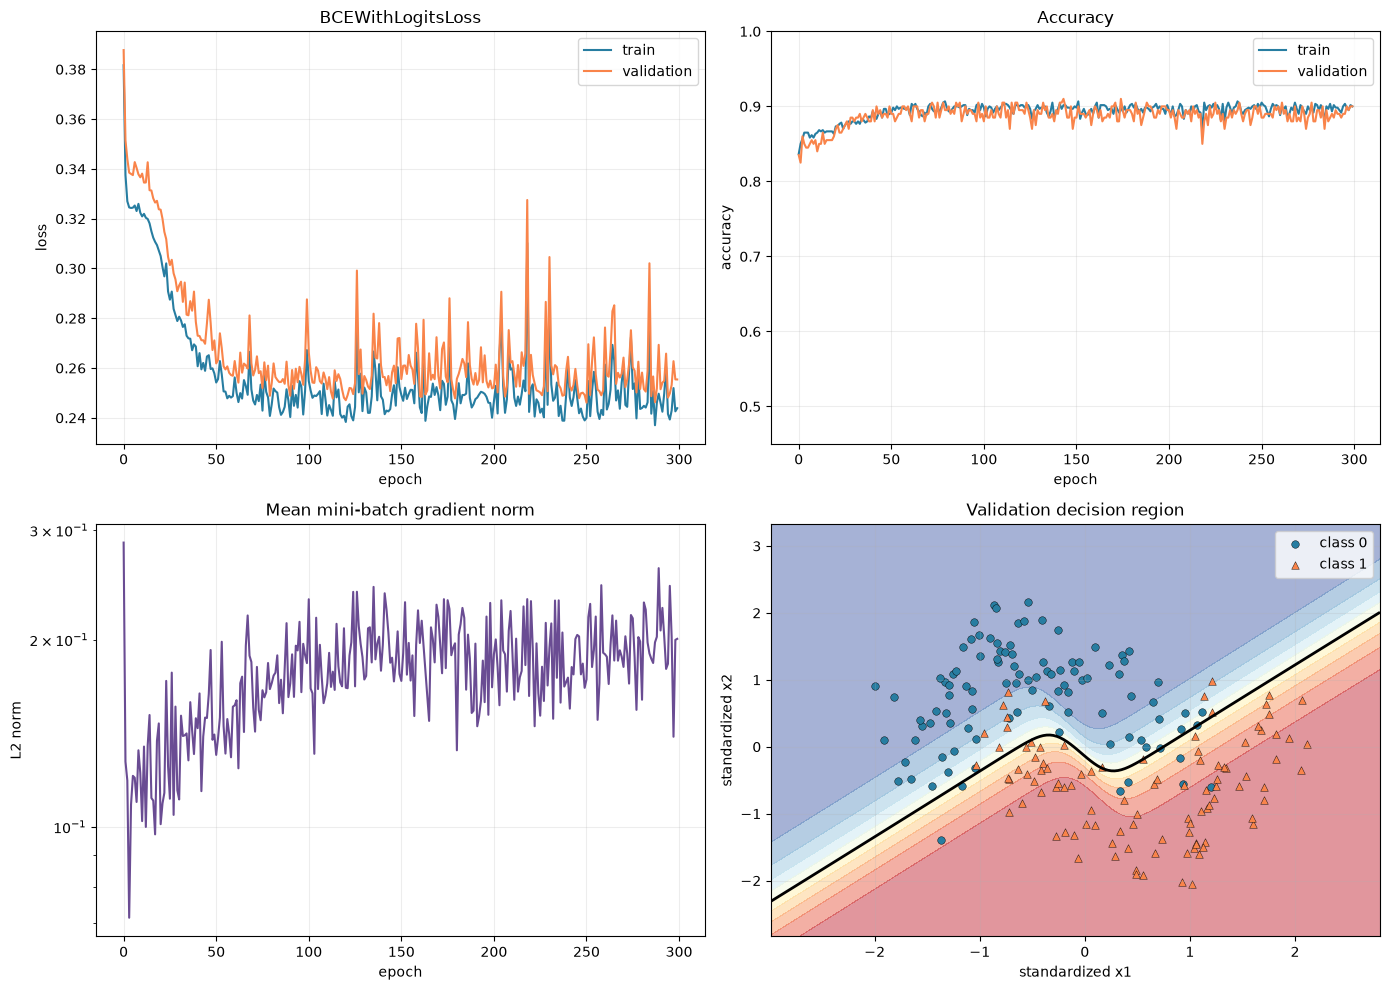

In [12]:
def boundary_probabilities(model, mesh):
    model.eval()
    with torch.inference_mode():
        logits = model(torch.tensor(mesh, dtype=torch.float32, device=DEVICE))
        return torch.sigmoid(logits).cpu().numpy().ravel()

x1 = np.linspace(min(X_train[:, 0].min(), X_val[:, 0].min()) - 0.6, max(X_train[:, 0].max(), X_val[:, 0].max()) + 0.6, 180)
x2 = np.linspace(min(X_train[:, 1].min(), X_val[:, 1].min()) - 0.6, max(X_train[:, 1].max(), X_val[:, 1].max()) + 0.6, 180)
xx1, xx2 = np.meshgrid(x1, x2)
mesh = np.column_stack([xx1.ravel(), xx2.ravel()])
mesh_probability = boundary_probabilities(baseline_model, mesh).reshape(xx1.shape)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(baseline_history['train_loss'], label='train', color='#277da1')
axes[0, 0].plot(baseline_history['val_loss'], label='validation', color='#f9844a')
axes[0, 0].set(title='BCEWithLogitsLoss', xlabel='epoch', ylabel='loss')
axes[0, 0].legend()
axes[0, 1].plot(baseline_history['train_accuracy'], label='train', color='#277da1')
axes[0, 1].plot(baseline_history['val_accuracy'], label='validation', color='#f9844a')
axes[0, 1].set(title='Accuracy', xlabel='epoch', ylabel='accuracy', ylim=(0.45, 1.0))
axes[0, 1].legend()
axes[1, 0].plot(baseline_history['gradient_norm'], color='#6a4c93')
axes[1, 0].set(title='Mean mini-batch gradient norm', xlabel='epoch', ylabel='L2 norm', yscale='log')
axes[1, 1].contourf(xx1, xx2, mesh_probability, levels=np.linspace(0, 1, 11), cmap='RdYlBu_r', alpha=0.45)
axes[1, 1].contour(xx1, xx2, mesh_probability, levels=[0.5], colors='black', linewidths=2)
for label, marker, color in [(0, 'o', '#277da1'), (1, '^', '#f9844a')]:
    mask = y_val_flat == label
    axes[1, 1].scatter(X_val[mask, 0], X_val[mask, 1], marker=marker, color=color, edgecolor='black', linewidth=0.3, s=30, label=f'class {label}')
axes[1, 1].set(title='Validation decision region', xlabel='standardized x1', ylabel='standardized x2')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

## Model Detective: Evidence Before Faulty Source

Choose or receive one card. Do not inspect the later source fragments until you submit two observations, two plausible causes, the cheapest discriminating check, a predicted result, and a rejection condition. Curve symptoms are not unique fingerprints.

| Card | Evidence available now |
|---|---|
| A | Loss falls slightly then stalls near the linear baseline; gradients are finite; no shape error |
| B | Early loss falls; later values become jagged; gradient norms grow across mini-batches |
| C | Repeated validation passes disagree for identical examples; a mode-sensitive module is present |
| D | Shapes are valid, loss changes slowly, and probability quality looks inconsistent with the loss contract |

### Instructor Hint Ladder: Evidence Before Source

For each card: (1) name two observations without naming a defect; (2) list at least two plausible causes;
(3) choose one cheap check that separates them; (4) predict the check; (5) state what would reject the
favored cause. Do not let curve shape become a unique fingerprint.

In [13]:
assigned_card = "A"
assigned_cards = ("A", "B", "C", "D")
evidence_only_diagnoses = {
    "A": {
        "two_observations": "Loss stalls near the linear baseline; gradients are finite and shapes pass.",
        "two_plausible_causes": "Missing hidden nonlinearity, or an optimization setting that never uses the nonlinear capacity.",
        "cheapest_discriminating_check": "Inspect the boundary family and whether a nonlinear operation lies between the two affine layers.",
        "predicted_check_result": "The effective model is affine-to-affine, so the 0.5 boundary is linear.",
        "rejection_condition": "Reject missing nonlinearity if a hidden nonlinear transform is active and the learned boundary is curved.",
    },
    "B": {
        "two_observations": "Loss becomes jagged after early progress; gradient norms grow across batches.",
        "two_plausible_causes": "Gradients are not reset, or the learning rate is too high.",
        "cheapest_discriminating_check": "Inspect .grad immediately after plain zero_grad and before the next backward; optimized gradients should be None.",
        "predicted_check_result": "Prior-batch gradient tensors remain and accumulate when reset is omitted; the plain reset replaces existing optimized gradients with None.",
        "rejection_condition": "Reject omitted reset if every batch calls plain zero_grad and pre-backward optimized .grad fields are None.",
    },
    "C": {
        "two_observations": "Identical validation inputs produce varying outputs; a dropout module is present.",
        "two_plausible_causes": "The model remains in training mode, or a different input/seed is entering each pass.",
        "cheapest_discriminating_check": "Check model.training and repeat under model.eval() plus inference_mode().",
        "predicted_check_result": "Evaluation mode removes dropout variation; inference mode also makes outputs not require gradients.",
        "rejection_condition": "Reject mode misuse if inputs are identical, model.training is False, and repeats still differ materially.",
    },
    "D": {
        "two_observations": "Shapes pass, but loss and probability quality disagree; learning stalls near chance.",
        "two_plausible_causes": "Sigmoid probabilities are being passed to BCEWithLogitsLoss, or targets/loss reduction are semantically wrong.",
        "cheapest_discriminating_check": "Inspect the model output range and the exact loss contract at their boundary.",
        "predicted_check_result": "Outputs are already in [0,1], so BCEWithLogitsLoss applies a second sigmoid interpretation.",
        "rejection_condition": "Reject wrong output/loss pairing if the model returns unconstrained raw logits to BCEWithLogitsLoss.",
    },
}
assert set(evidence_only_diagnoses) == set(assigned_cards)
assert all(
    all(value.strip() for value in diagnosis.values())
    for diagnosis in evidence_only_diagnoses.values()
)
evidence_only_diagnosis = evidence_only_diagnoses[assigned_card]
print("Instructor evidence-only diagnoses recorded for cards A-D.")

Instructor evidence-only diagnoses recorded for cards A-D.


## Source Reveal: Four One-Invariant Configurations

Only now inspect the configurable model and training/evaluation harness. Each card violates exactly one invariant: compatible raw output/loss, hidden nonlinearity, gradient reset, or evaluation mode/context.

In [14]:
class DiagnosticClassifier(nn.Module):
    def __init__(self, use_nonlinearity=True, output_probabilities=False):
        super().__init__()
        self.hidden = nn.Linear(2, 8)
        self.activation = nn.Tanh()
        self.dropout = nn.Dropout(0.15)
        self.output = nn.Linear(8, 1)
        self.use_nonlinearity = use_nonlinearity
        self.output_probabilities = output_probabilities

    def forward(self, X):
        hidden = self.hidden(X)
        activated = self.activation(hidden) if self.use_nonlinearity else hidden
        logits = self.output(self.dropout(activated))
        return torch.sigmoid(logits) if self.output_probabilities else logits

BASE_DIAGNOSTIC_CONFIG = {
    "use_nonlinearity": True,
    "output_probabilities": False,
    "reset_gradients": True,
    "proper_evaluation": True,
}
CARD_TO_DEFECT = {
    "A": 'missing_nonlinearity',
    "B": 'omitted_gradient_reset',
    "C": 'mode_misuse',
    "D": 'wrong_output_loss',
}
assigned_defect = CARD_TO_DEFECT[assigned_card]

In [15]:
def defect_configuration(defect):
    config = BASE_DIAGNOSTIC_CONFIG.copy()
    if defect == 'missing_nonlinearity':
        config['use_nonlinearity'] = False
    elif defect == 'omitted_gradient_reset':
        config['reset_gradients'] = False
    elif defect == 'mode_misuse':
        config['proper_evaluation'] = False
    elif defect == 'wrong_output_loss':
        config['output_probabilities'] = True
    else:
        raise ValueError(f"Unknown defect: {defect}")
    return config

def diagnostic_evaluate(model, config):
    if config['proper_evaluation']:
        model.eval()
        with torch.inference_mode():
            outputs = [model(X_val_tensor) for _ in range(3)]
    else:
        model.train()
        outputs = [model(X_val_tensor) for _ in range(3)]
    first_output = outputs[0]
    probabilities = torch.sigmoid(first_output)
    stacked = torch.stack([torch.sigmoid(output.detach()) for output in outputs])
    return {
        "loss": float(nn.BCEWithLogitsLoss()(first_output, y_val_tensor).detach().item()),
        "accuracy": float(((probabilities >= 0.5) == y_val_tensor.bool()).float().mean().detach().item()),
        "repeat_std": float(stacked.std(dim=0).mean().item()),
        "outputs_require_grad": bool(first_output.requires_grad),
    }

def run_diagnostic(config, epochs=180):
    set_all_seeds(MODEL_SEED)
    model = DiagnosticClassifier(config['use_nonlinearity'], config['output_probabilities']).to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.6)
    criterion = nn.BCEWithLogitsLoss()
    loader = make_train_loader(64, BATCH_SEED)
    history = {"train_loss": [], "gradient_norm": [], "val_loss": [], "val_accuracy": []}
    for _ in range(epochs):
        model.train()
        losses, norms = [], []
        for X_batch, y_batch in loader:
            if config['reset_gradients']:
                optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            norms.append(total_gradient_norm(model))
            optimizer.step()
            losses.append(float(loss.detach().item()))
        evidence = diagnostic_evaluate(model, config)
        history['train_loss'].append(float(np.mean(losses)))
        history['gradient_norm'].append(float(np.mean(norms)))
        history['val_loss'].append(evidence['loss'])
        history['val_accuracy'].append(evidence['accuracy'])
    return model, history, evidence

## Challenge: Repair Exactly One Invariant

Complete `repair_configuration`. Start from the assigned faulty configuration and change only the field that restores its violated invariant. Predict the evidence change before either run. The check rejects broad rewrites that change more than one field.

In [16]:
repair_predictions = {
    "A": {
        "curve": "Loss should move below the linear plateau.",
        "gradient_norm": "Norms should remain finite; no explosion is required for this repair.",
        "accuracy_or_repeatability": "Accuracy should return to roughly 0.85-0.95 with a nonlinear boundary.",
        "mechanism": "Restoring tanh prevents two affine layers from collapsing to one affine map.",
    },
    "B": {
        "curve": "Jagged/unstable loss should become a stable decreasing trace.",
        "gradient_norm": "Large accumulated norms should return to a bounded range.",
        "accuracy_or_repeatability": "Accuracy should recover from the degraded accumulated-gradient run.",
        "mechanism": "Resetting before each backward makes .grad represent the current mini-batch only.",
    },
    "C": {
        "curve": "Validation evidence should become deterministic across repeated passes.",
        "gradient_norm": "Training gradients are unchanged; evaluation should no longer record gradients.",
        "accuracy_or_repeatability": "Repeat std should become zero and outputs_require_grad should become False.",
        "mechanism": "eval disables dropout sampling and inference_mode disables autograd recording.",
    },
    "D": {
        "curve": "Loss should align with raw-logit probability quality and decrease further.",
        "gradient_norm": "Gradients should reflect the intended stable logits loss.",
        "accuracy_or_repeatability": "Accuracy should recover from about chance to the sanity band.",
        "mechanism": "Returning logits removes the accidental double sigmoid interpretation.",
    },
}
assert all(all(value.strip() for value in prediction.values()) for prediction in repair_predictions.values())

def repair_configuration(defect, broken_config):
    repaired = broken_config.copy()
    repairs = {
        'missing_nonlinearity': ('use_nonlinearity', True),
        'omitted_gradient_reset': ('reset_gradients', True),
        'mode_misuse': ('proper_evaluation', True),
        'wrong_output_loss': ('output_probabilities', False),
    }
    field, value = repairs[defect]
    repaired[field] = value
    return repaired

expected_fields = {
    'missing_nonlinearity': 'use_nonlinearity',
    'omitted_gradient_reset': 'reset_gradients',
    'mode_misuse': 'proper_evaluation',
    'wrong_output_loss': 'output_probabilities',
}
repair_configs = {}
for card in assigned_cards:
    defect = CARD_TO_DEFECT[card]
    broken = defect_configuration(defect)
    repaired = repair_configuration(defect, broken)
    changed = [name for name in broken if broken[name] != repaired[name]]
    assert changed == [expected_fields[defect]]
    assert repaired == BASE_DIAGNOSTIC_CONFIG
    repair_configs[card] = {"broken": broken, "repaired": repaired, "changed_fields": changed}

broken_config = repair_configs[assigned_card]["broken"]
repaired_config = repair_configs[assigned_card]["repaired"]
repair_prediction = repair_predictions[assigned_card]
changed_fields = repair_configs[assigned_card]["changed_fields"]
expected_field = expected_fields[assigned_defect]

Card A defect: missing_nonlinearity
  Broken evidence: {'loss': 0.33426225185394287, 'accuracy': 0.8500000238418579, 'repeat_std': 0.0, 'outputs_require_grad': False}
  Repaired evidence: {'loss': 0.24782250821590424, 'accuracy': 0.8949999809265137, 'repeat_std': 0.0, 'outputs_require_grad': False}


Card B defect: omitted_gradient_reset
  Broken evidence: {'loss': 4.259652137756348, 'accuracy': 0.6899999976158142, 'repeat_std': 0.0, 'outputs_require_grad': False}
  Repaired evidence: {'loss': 0.24782250821590424, 'accuracy': 0.8949999809265137, 'repeat_std': 0.0, 'outputs_require_grad': False}


Card C defect: mode_misuse
  Broken evidence: {'loss': 0.2769661247730255, 'accuracy': 0.8650000095367432, 'repeat_std': 0.06524975597858429, 'outputs_require_grad': True}
  Repaired evidence: {'loss': 0.24782250821590424, 'accuracy': 0.8949999809265137, 'repeat_std': 0.0, 'outputs_require_grad': False}


Card D defect: wrong_output_loss
  Broken evidence: {'loss': 0.573136568069458, 'accuracy': 0.5, 'repeat_std': 0.0, 'outputs_require_grad': False}
  Repaired evidence: {'loss': 0.24782250821590424, 'accuracy': 0.8949999809265137, 'repeat_std': 0.0, 'outputs_require_grad': False}


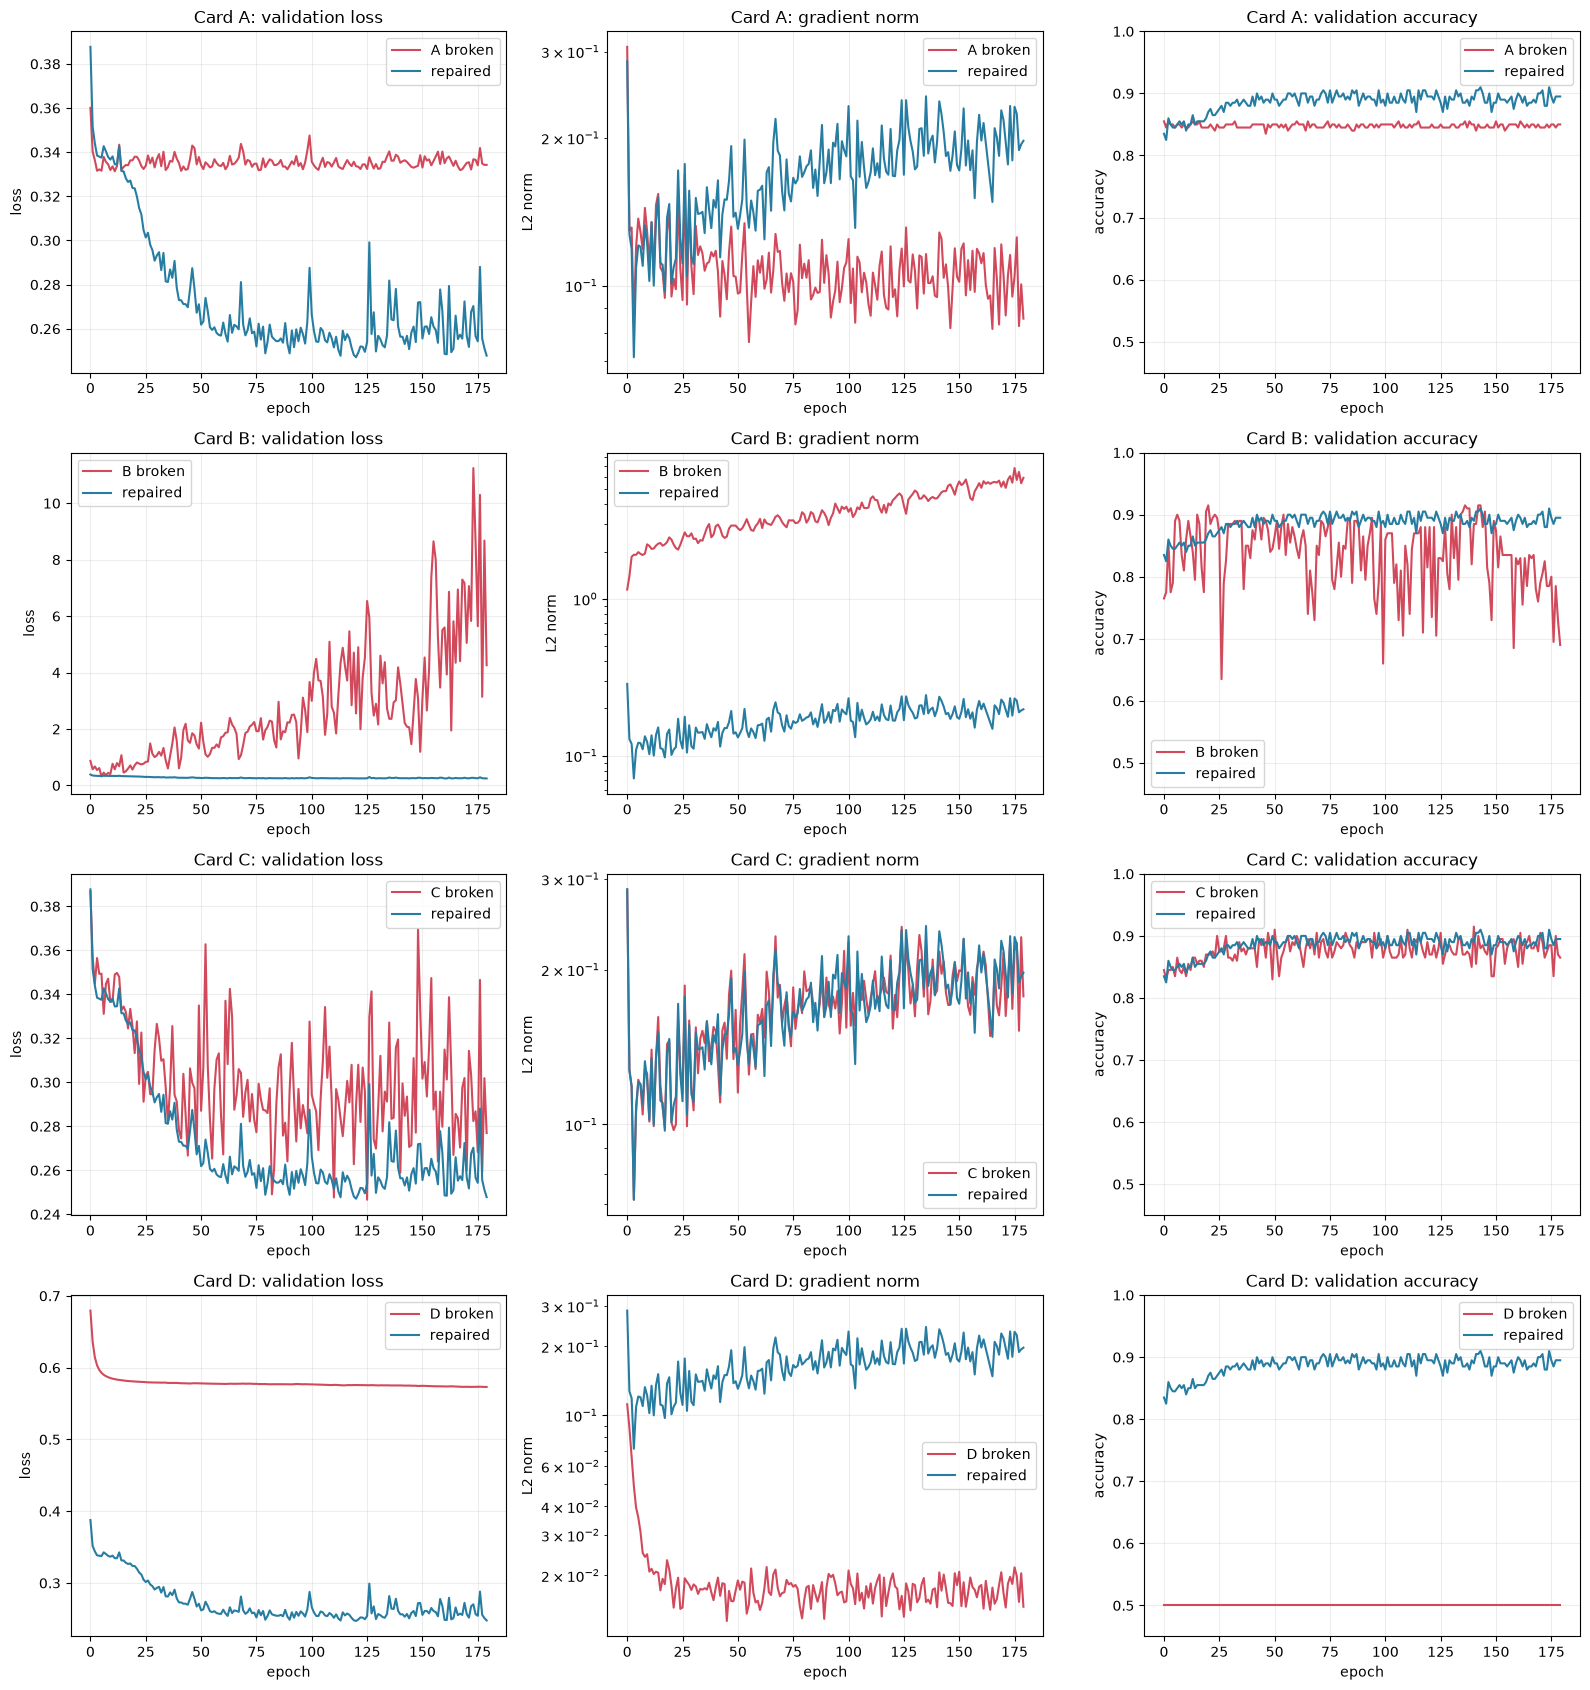

In [17]:
repaired_model, repaired_history, repaired_evidence = run_diagnostic(BASE_DIAGNOSTIC_CONFIG)
all_card_runs = {}
for card in assigned_cards:
    defect = CARD_TO_DEFECT[card]
    broken_model, broken_history, broken_evidence = run_diagnostic(repair_configs[card]["broken"])
    all_card_runs[card] = {
        "defect": defect,
        "broken_model": broken_model,
        "broken_history": broken_history,
        "broken_evidence": broken_evidence,
        "repaired_history": repaired_history,
        "repaired_evidence": repaired_evidence,
    }
    print(f"Card {card} defect: {defect}")
    print("  Broken evidence:", broken_evidence)
    print("  Repaired evidence:", repaired_evidence)

fig, axes = plt.subplots(4, 3, figsize=(16, 17))
for row, card in enumerate(assigned_cards):
    run = all_card_runs[card]
    broken_history = run["broken_history"]
    axes[row, 0].plot(broken_history['val_loss'], label=f'{card} broken', color='#d1495b')
    axes[row, 0].plot(repaired_history['val_loss'], label='repaired', color='#277da1')
    axes[row, 0].set(title=f'Card {card}: validation loss', xlabel='epoch', ylabel='loss')
    axes[row, 0].legend()
    axes[row, 1].plot(broken_history['gradient_norm'], label=f'{card} broken', color='#d1495b')
    axes[row, 1].plot(repaired_history['gradient_norm'], label='repaired', color='#277da1')
    axes[row, 1].set(title=f'Card {card}: gradient norm', xlabel='epoch', ylabel='L2 norm', yscale='log')
    axes[row, 1].legend()
    axes[row, 2].plot(broken_history['val_accuracy'], label=f'{card} broken', color='#d1495b')
    axes[row, 2].plot(repaired_history['val_accuracy'], label='repaired', color='#277da1')
    axes[row, 2].set(title=f'Card {card}: validation accuracy', xlabel='epoch', ylabel='accuracy', ylim=(0.45, 1.0))
    axes[row, 2].legend()
plt.tight_layout()
plt.show()

broken_model = all_card_runs[assigned_card]["broken_model"]
broken_history = all_card_runs[assigned_card]["broken_history"]
broken_evidence = all_card_runs[assigned_card]["broken_evidence"]
assert 0.85 <= repaired_evidence['accuracy'] <= 0.95
assert repaired_evidence['repeat_std'] < 1e-8
assert repaired_evidence['outputs_require_grad'] is False
assert all_card_runs['A']['broken_evidence']['accuracy'] <= repaired_evidence['accuracy']
assert max(all_card_runs['B']['broken_history']['gradient_norm']) > 1.0
assert all_card_runs['C']['broken_evidence']['repeat_std'] > 1e-3
assert all_card_runs['C']['broken_evidence']['outputs_require_grad'] is True
assert all_card_runs['D']['broken_evidence']['accuracy'] < 0.60

### Instructor Reveal: All-Card Reference Evidence

Expected local signatures are broad rather than exact: A remains near the linear limit (`~0.850`);
B degrades with norms rising above `6`; C has nonzero repeat variation (`~0.065`) and tracked outputs;
D remains near chance (`~0.500`). The common one-field repair returns accuracy near `0.895`, repeat
variation to zero, and evaluation outputs without gradients.

**Fast recovery:** If a live all-card run is too slow, show the stored evidence table/plots, execute one
assigned broken card plus the common repaired config, and retain the one-field configuration assertions.

## Explain the Repair

Cite the symptom, competing hypothesis, discriminating check, violated invariant, one-field repair, before/after evidence, and mechanism. State one remaining uncertainty: the repaired classroom run does not make every larger training symptom uniquely diagnosable.

In [18]:
repair_diagnoses = {
    "A": {
        "symptom": "Finite gradients but a linear-limit plateau near 0.85 accuracy.",
        "competing_hypothesis": "The rate could be poor even with adequate nonlinear capacity.",
        "discriminating_check": "Inspect the active hidden transform and boundary family.",
        "violated_invariant": "A nonlinear hidden transform must separate the two affine stages.",
        "targeted_repair": "Set use_nonlinearity=True only.",
        "before_after_evidence": "Accuracy rises from about 0.850 to 0.895 and loss from about 0.334 to 0.248, with the nonlinear path restored.",
        "why_it_worked": "Tanh creates nonlinear hidden features so the composition can form a curved boundary.",
        "remaining_uncertainty": "A similar plateau in another model could still come from data, optimization, or regularization.",
    },
    "B": {
        "symptom": "Jagged loss, degraded accuracy, and gradient norms growing to several times the repaired range.",
        "competing_hypothesis": "An excessive rate can also create unstable curves.",
        "discriminating_check": "Check whether gradients are cleared before each backward pass.",
        "violated_invariant": "Each ordinary mini-batch update must start with reset gradients.",
        "targeted_repair": "Set reset_gradients=True only.",
        "before_after_evidence": "Accuracy recovers from about 0.69 to 0.895; max norms fall from about 6.8 to below 0.3.",
        "why_it_worked": "Each step now uses the current batch gradient instead of an unintended running sum.",
        "remaining_uncertainty": "Intentional gradient accumulation is valid when loss scaling and update cadence are designed for it.",
    },
    "C": {
        "symptom": "Repeated validation outputs vary and still require gradients.",
        "competing_hypothesis": "Input mutation or an uncontrolled random transform could also vary outputs.",
        "discriminating_check": "Check model.training, repeat under eval, and inspect requires_grad inside inference_mode.",
        "violated_invariant": "Evaluation needs deterministic module mode and a separate gradient-disabled context.",
        "targeted_repair": "Set proper_evaluation=True only.",
        "before_after_evidence": "Repeat std falls from roughly 0.065 to 0; outputs_require_grad changes True to False; accuracy stabilizes near 0.895.",
        "why_it_worked": "eval stops dropout sampling and inference_mode stops graph recording.",
        "remaining_uncertainty": "Other stochastic layers, data transforms, or distributed effects can also create evaluation variance.",
    },
    "D": {
        "symptom": "Shapes pass, but loss stalls and accuracy remains near 0.50.",
        "competing_hypothesis": "Targets or threshold logic could be wrong despite valid shapes.",
        "discriminating_check": "Inspect whether model outputs are raw logits or already sigmoid probabilities.",
        "violated_invariant": "BCEWithLogitsLoss must receive raw logits, not probabilities.",
        "targeted_repair": "Set output_probabilities=False only.",
        "before_after_evidence": "Accuracy rises from about 0.50 to 0.895 and loss falls from about 0.573 to 0.248.",
        "why_it_worked": "The stable loss now applies exactly one sigmoid interpretation to unconstrained logits.",
        "remaining_uncertainty": "A chance-level run can have many causes, so output range is the discriminating evidence here.",
    },
}
assert all(all(value.strip() for value in diagnosis.values()) for diagnosis in repair_diagnoses.values())
repair_diagnosis = repair_diagnoses[assigned_card]
print("Instructor repair diagnoses recorded for cards A-D.")

Instructor repair diagnoses recorded for cards A-D.


## Inspect the Mode/Gradient Distinction Directly

Even if your assigned card was different, verify this semantic distinction: `eval()` changes dropout behavior, while gradient recording remains enabled until a no-grad or inference context is entered. Predict both `requires_grad` values before running.

### Instructor Discussion Trigger: Two Independent Controls

Ask: “What changes if we call only `eval()`?” Then ask: “What changes if we use an inference context
without `eval()` while dropout remains active?” The first can still record gradients; the second can
still sample training-mode dropout. Correct evaluation needs both concerns addressed.

In [19]:
mode_prediction = {
    "eval_only_requires_grad": "True: eval changes dropout behavior but leaves autograd enabled.",
    "inference_context_requires_grad": "False: inference_mode disables gradient recording for operations inside the context.",
}
assert all(value.strip() for value in mode_prediction.values())
baseline_model.eval()
eval_only_logits = baseline_model(X_val_tensor[:8])
with torch.inference_mode():
    inference_logits = baseline_model(X_val_tensor[:8])
print("eval() only -> requires_grad:", eval_only_logits.requires_grad)
print("eval() + inference_mode() -> requires_grad:", inference_logits.requires_grad)
assert eval_only_logits.requires_grad is True
assert inference_logits.requires_grad is False

eval() only -> requires_grad: True
eval() + inference_mode() -> requires_grad: False


## Optional Extension: Shape Mismatch Diagnostic

Predict the exception category when logits have shape `(B, 1)` but targets are flattened to `(B,)`. Run the mismatch inside a caught block, then recover by restoring the explicit target dimension. This extension is not required by the core checkpoint.

In [20]:
optional_shape_prediction = "BCEWithLogitsLoss should raise ValueError because target (16,) does not exactly match logits (16,1)."
if not optional_shape_prediction.strip():
    print("Optional shape diagnostic skipped. Core checkpoint is unaffected.")
else:
    baseline_model.eval()
    with torch.inference_mode():
        optional_logits = baseline_model(X_val_tensor[:16])
    shape_failure_observed = False
    try:
        loss_fn(optional_logits, y_val_tensor[:16].ravel())
    except ValueError as error:
        shape_failure_observed = True
        print("Expected shape mismatch:", error)
    recovered_loss = loss_fn(optional_logits, y_val_tensor[:16])
    assert shape_failure_observed and torch.isfinite(recovered_loss)
    optional_shape_interpretation = (
        "Equal element counts do not define elementwise alignment. The loss contract requires the "
        "target shape to match the binary logit shape, so restoring (B,1) removes ambiguous broadcasting."
    )
    assert optional_shape_interpretation.strip()
    print("Instructor shape interpretation:", optional_shape_interpretation)

Expected shape mismatch: Target size (torch.Size([16])) must be the same as input size (torch.Size([16, 1]))
Instructor shape interpretation: Equal element counts do not define elementwise alignment. The loss contract requires the target shape to match the binary logit shape, so restoring (B,1) removes ambiguous broadcasting.


## Reflect and Checkpoint

Map every framework call back to a NumPy responsibility. Explain what autograd automated, what judgment remained yours, and which evidence would catch the assigned defect in a larger run.

### Instructor Debrief and Delivery Notes

**Common failures and misconceptions:** Sigmoid inside the model creates the wrong logits/loss contract; target `(B,)` does not match logits `(B,1)`; omitting reset accumulates gradients; calling `eval()` without a no-grad context still records operations; calling an inference context without `eval()` leaves dropout active; moving only the model or only data to an accelerator creates a device mismatch. Plain PyTorch 2.11 `zero_grad()` does not supply visible zero tensors: its default is `set_to_none=True`. A parameter unused by backward remains `None`, including after explicit `set_to_none=False` if no gradient buffer was ever materialized.

**Probe demo:** Before discussing card B, ask learners to predict the four printed states and whether weight decay can move a parameter whose gradient tensor is numerically zero. Run only the independent gradient-state probe. It does not reference or mutate the baseline model, diagnostic models, data, or RNG.

**CPU/GPU/Colab:** CPU is the required baseline and produces the release evidence. CUDA/MPS availability is informational; different devices may change last digits and timing. A hosted Colab CPU and exact PyTorch 2.11 runtime were not executed, so neither is claimed as validated.

**Acceptable alternatives:** `torch.no_grad()` is valid for evaluation. Explicit `optimizer.zero_grad(set_to_none=False)` is valid when zero-filled existing buffers are intentionally required, but inspection must still allow a never-materialized unused gradient to remain `None`. `Adam` can train the baseline but changes the experiment contract and evidence bands. Repairs are valid only when they restore the single violated invariant.

**Fast recovery:** If a live all-card run is too slow, retain the one-field configuration assertions, show the stored all-card evidence, and execute one assigned broken card plus the common repaired configuration. If the probe is interrupted, rerun only that cell and compare its four printed states with the official 2.11 API note above.

In [21]:
reflection = {
    "framework_to_numpy_mapping": "DataLoader performs seeded mini-batch indexing; nn.Linear computes X @ W.T + b because PyTorch stores weight as (d_out,d_in); nn.Tanh matches np.tanh; Dropout applies a stochastic masked/scaled hidden activation in train mode and identity behavior in eval; BCEWithLogitsLoss is stable sigmoid+BCE; plain zero_grad replaces existing optimized gradients with None by default; backward performs the cached chain rule and materializes tensors only for receiving parameters; total_gradient_norm mirrors the NumPy sum-of-squares norm while skipping None; SGD.step applies parameter -= eta*grad and skips None gradients; eval controls module mode; inference_mode disables graph recording; torch.sigmoid converts logits for metrics.",
    "autograd_automated": "Autograd recorded tensor operations, propagated local derivatives, summed parameter gradients, and exposed receiving gradients in .grad; modules registered parameters and the optimizer applied updates while skipping None gradients.",
    "judgment_remained": "The engineer still chose the split, architecture, logits/loss contract, target shape, optimizer order, reset representation, mode/context, metrics, evidence, thresholds, seeds, and targeted repair.",
    "larger_run_detection": "Track boundary/capacity evidence for A, pre-backward None states and norm growth for B, repeated-evaluation variance plus mode/context for C, and output range plus loss contract for D; no single curve uniquely identifies a defect.",
}
assert all(value.strip() for value in reflection.values())
assert 0.85 <= baseline_val_evidence['accuracy'] <= 0.95
assert 0.85 <= repaired_evidence['accuracy'] <= 0.95
assert changed_fields == [expected_field]
assert repaired_evidence['repeat_std'] < 1e-8
assert repaired_evidence['outputs_require_grad'] is False
assert eval_only_logits.requires_grad and not inference_logits.requires_grad
assert baseline_seconds < 120.0
assert set(all_card_runs) == set(assigned_cards)
assert shape_failure_observed and torch.isfinite(recovered_loss)
assert gradient_probe_evidence['plain_default_reset'] == {'used': 'None', 'unused': 'None'}
assert gradient_probe_evidence['after_backward'] == {'used': 'Tensor', 'unused': 'None'}
assert gradient_probe_evidence['explicit_zero_buffer'] == {'used_sum': 0.0, 'unused': 'None'}
assert gradient_probe_evidence['optimizer_none_vs_zero']['none_gradient_value'] == 1.0
assert np.isclose(gradient_probe_evidence['optimizer_none_vs_zero']['zero_gradient_value'], 0.9)
print("LAB-D2-04 checkpoint passed: logits/loss contract, optimizer order, None-aware reset semantics, mode semantics, gradient evidence, all four targeted repairs, and shape recovery.")

LAB-D2-04 checkpoint passed: logits/loss contract, optimizer order, None-aware reset semantics, mode semantics, gradient evidence, all four targeted repairs, and shape recovery.


## Takeaways

- `BCEWithLogitsLoss` pairs raw logits with same-shaped binary targets.
- `backward()` computes and accumulates gradients; `step()` updates parameters.
- Plain PyTorch 2.11 `zero_grad()` defaults to `set_to_none=True`; inspect `.grad` with `None` in mind, and use explicit `set_to_none=False` only for the zero-filled existing-buffer contrast.
- Parameters that receive no gradient remain `None`, and optimizers distinguish `None` from a zero tensor.
- Gradient reset belongs before each new mini-batch backward pass unless accumulation is intentional.
- `eval()` controls mode-sensitive modules; an inference context controls gradient recording.
- PyTorch automates mechanics, but evidence-first diagnosis and objective choice remain engineering decisions.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| `ModuleNotFoundError: torch` | Selected kernel lacks PyTorch | Select the course kernel or install the course-compatible PyTorch build, then restart |
| Loss rejects target size | Logits `(B,1)` and targets `(B,)` differ | Preserve the explicit binary output dimension |
| Loss behaves oddly with values in `[0,1]` | Sigmoid was applied before `BCEWithLogitsLoss` | Return raw logits and apply sigmoid only for metrics |
| `.grad.detach()` fails immediately after reset | Code assumed plain `zero_grad()` created a tensor | Treat `None` as the expected PyTorch 2.11 default state; inspect tensors only after a receiving backward pass |
| Explicit `set_to_none=False` leaves an unused parameter at `None` | That parameter never had a gradient buffer to zero-fill | This is expected; the explicit call zeroes existing buffers but need not materialize a never-used one |
| Gradient norms grow across batches | Gradients were not reset | Call plain `optimizer.zero_grad()` before the next backward pass |
| Validation outputs change between repeats | Model remained in training mode with dropout active | Call `model.eval()` before evaluation |
| Evaluation logits still require gradients | `eval()` was mistaken for gradient disabling | Add `torch.inference_mode()` or `torch.no_grad()` |
| Results differ from the sanity band | Seeds, split, mode, or device changed | Restart, restore CPU and supplied constants, and run in order |

## Continue

Return to the [LAB-D2-04 debrief](../../day-2/student-guide/day-2-student-guide.md#lab-d2-04---pytorch-autograd-break-it-and-fix-it). Review [LESSON-D2-06](../../day-2/student-guide/day-2-student-guide.md#lesson-d2-06---what-pytorch-automates), [LESSON-D2-07](../../day-2/student-guide/day-2-student-guide.md#lesson-d2-07---evidence-first-training-diagnosis), [ACT-D2-04](../../day-2/challenges/day-2-challenges.md#act-d2-04---broken-curve-detective), and the [LAB-D2-03 instructor solution](LAB-D2-03-numpy-training-SOLUTION.ipynb) as needed.